In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns       
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
from io import StringIO


In [3]:
#Load the datasets
price_path_1 = "CSV Data\prices_round_0_day_-1.csv"
trades_path_1 = "CSV Data/trades_round_0_day_-1.csv"
price_path_2 = "CSV Data/prices_round_0_day_-2.csv"
trades_path_2 = "CSV Data/trades_round_0_day_-2.csv"


prices_data_01 = pd.read_csv(price_path_1, sep=";")
trades_data_01 = pd.read_csv(trades_path_1, sep=";")
prices_data_02 = pd.read_csv(price_path_2, sep=";")
trades_data_02 = pd.read_csv(trades_path_2, sep=";")



print(prices_data_01.shape[0])
print(trades_data_01.shape[0])

prices_data_02.head(20)

20000
631


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,11,10010,25,NaN,NaN,10000.0,0.0
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,7,5008,17,NaN,NaN,5000.0,0.0
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,7,5008,16,NaN,NaN,5002.5,0.0
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,6,5009,20,NaN,NaN,5001.0,0.0
5,-2,200,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0
6,-2,300,EMERALDS,9992,13,9990,26,NaN,NaN,10008,13,10010,26,NaN,NaN,10000.0,0.0
7,-2,300,TOMATOES,4995,5,4993,21,NaN,NaN,5008,5,5009,21,NaN,NaN,5001.5,0.0
8,-2,400,EMERALDS,9992,15,9990,20,NaN,NaN,10008,15,10010,20,NaN,NaN,10000.0,0.0
9,-2,400,TOMATOES,4995,8,4993,20,NaN,NaN,5008,8,5009,20,NaN,NaN,5001.5,0.0


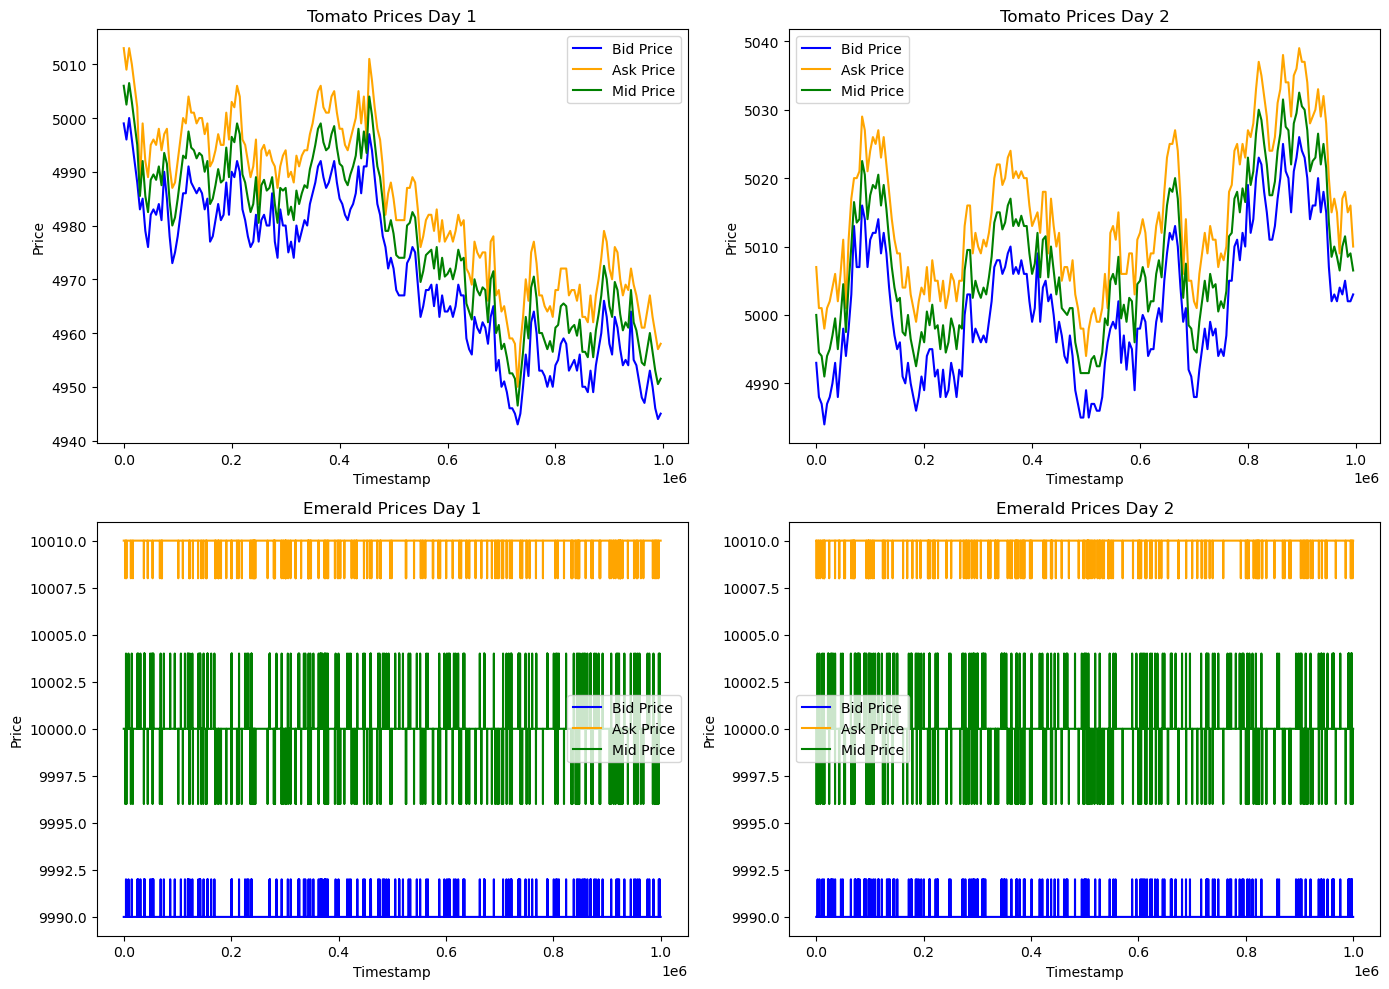

In [4]:
# split tomato and emerald data
prices_data_01_Tomato = prices_data_01[prices_data_01['product'] == 'TOMATOES'].drop(columns=['product']).copy()
prices_data_01_Emerald = prices_data_01[prices_data_01['product'] == 'EMERALDS'].drop(columns=['product']).copy()
prices_data_02_Tomato = prices_data_02[prices_data_02['product'] == 'TOMATOES'].drop(columns=['product']).copy()
prices_data_02_Emerald = prices_data_02[prices_data_02['product'] == 'EMERALDS'].drop(columns=['product']).copy()

trades_data_01_Tomato = trades_data_01[trades_data_01['symbol'] == 'TOMATOES'].drop(columns=['symbol']).copy()
trades_data_01_Emerald = trades_data_01[trades_data_01['symbol'] == 'EMERALDS'].drop(columns=['symbol']).copy()
trades_data_02_Tomato = trades_data_02[trades_data_02['symbol'] == 'TOMATOES'].drop(columns=['symbol']).copy()
trades_data_02_Emerald = trades_data_02[trades_data_02['symbol'] == 'EMERALDS'].drop(columns=['symbol']).copy()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# tomatoes day 1
ax1.plot(prices_data_01_Tomato["timestamp"][::50], prices_data_01_Tomato["bid_price_1"][::50], label="Bid Price", color="blue")
ax1.plot(prices_data_01_Tomato["timestamp"][::50], prices_data_01_Tomato["ask_price_1"][::50], label="Ask Price", color="orange")
ax1.plot(prices_data_01_Tomato["timestamp"][::50], prices_data_01_Tomato["mid_price"][::50], label="Mid Price", color="green")
ax1.set_title("Tomato Prices Day 1")
ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Price")
ax1.legend()

# tomatoes day 2
ax2.plot(prices_data_02_Tomato["timestamp"][::50], prices_data_02_Tomato["bid_price_1"][::50], label="Bid Price", color="blue")
ax2.plot(prices_data_02_Tomato["timestamp"][::50], prices_data_02_Tomato["ask_price_1"][::50], label="Ask Price", color="orange")
ax2.plot(prices_data_02_Tomato["timestamp"][::50], prices_data_02_Tomato["mid_price"][::50], label="Mid Price", color="green")
ax2.set_title("Tomato Prices Day 2")
ax2.set_xlabel("Timestamp")
ax2.set_ylabel("Price")
ax2.legend()

# emeralds day 1
ax3.plot(prices_data_01_Emerald["timestamp"], prices_data_01_Emerald["bid_price_2"], label="Bid Price", color="blue")
ax3.plot(prices_data_01_Emerald["timestamp"], prices_data_01_Emerald["ask_price_2"], label="Ask Price", color="orange")
ax3.plot(prices_data_01_Emerald["timestamp"], prices_data_01_Emerald["mid_price"], label="Mid Price", color="green")
ax3.set_title("Emerald Prices Day 1")
ax3.set_xlabel("Timestamp")
ax3.set_ylabel("Price")
ax3.legend()

# emeralds day 2
ax4.plot(prices_data_02_Emerald["timestamp"], prices_data_02_Emerald["bid_price_2"], label="Bid Price", color="blue")
ax4.plot(prices_data_02_Emerald["timestamp"], prices_data_02_Emerald["ask_price_2"], label="Ask Price", color="orange")
ax4.plot(prices_data_02_Emerald["timestamp"], prices_data_02_Emerald["mid_price"], label="Mid Price", color="green")
ax4.set_title("Emerald Prices Day 2")
ax4.set_xlabel("Timestamp")
ax4.set_ylabel("Price")
ax4.legend()

plt.tight_layout()
plt.show()


In [5]:
#combine order book and trade data for tomatoes and emeralds
df_tom = prices_data_01_Tomato.merge(trades_data_01_Tomato, on=["timestamp"], how="left")
df_em = prices_data_01_Emerald.merge(trades_data_01_Emerald, on=["timestamp"], how="left")


trades_data_01_Tomato.head(20)

,timestamp,buyer,seller,currency,price,quantity
1,3400,NaN,NaN,XIRECS,5009.0,2
3,7000,NaN,NaN,XIRECS,5010.0,4
4,9600,NaN,NaN,XIRECS,4999.0,5
5,9900,NaN,NaN,XIRECS,5000.0,4
6,16400,NaN,NaN,XIRECS,4996.0,2
7,17900,NaN,NaN,XIRECS,5009.0,2
8,22200,NaN,NaN,XIRECS,5005.0,3
9,23500,NaN,NaN,XIRECS,4989.0,3
10,24600,NaN,NaN,XIRECS,5002.0,5
11,26100,NaN,NaN,XIRECS,4988.0,2


In [ ]:
with open("tutorial_trading_algo/60694.log", "r") as f:
    raw_text = f.read()

data = json.loads(raw_text)
log = data["activitiesLog"]

df = pd.read_csv(StringIO(log), sep=";")

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,TOMATOES,4999,6,4998,19,NaN,NaN,5013,6,5014,19,NaN,NaN,5006.0,0.0
1,-1,0,EMERALDS,9992,15,9990,30,NaN,NaN,10008,15,10010,30,NaN,NaN,10000.0,0.0
2,-1,100,EMERALDS,9992,13,9990,30,NaN,NaN,10008,13,10010,30,NaN,NaN,10000.0,0.0
3,-1,100,TOMATOES,5000,5,4998,23,NaN,NaN,5013,5,5014,23,NaN,NaN,5006.5,0.0
4,-1,200,EMERALDS,9992,13,9990,21,NaN,NaN,10008,13,10010,21,NaN,NaN,10000.0,0.0
